# AthleteIQ — Baseline Machine Learning Models

## Objective

Train and evaluate baseline machine learning models for predicting Quality of Sleep.

The goal is to establish initial performance benchmarks before attempting more advanced modeling techniques.

In [1]:
import pandas as pd
import numpy as np

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

## 1. Load Prepared Training and Testing Data

The feature engineering stage created separate training and testing datasets.

These files will be used to train and evaluate the baseline models.

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (299, 27)
X_test shape: (75, 27)
y_train shape: (299, 1)
y_test shape: (75, 1)


## 2. Verify Training and Testing Data

In [3]:
print("Missing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum().sum())

print("\nMissing values in y_train:")
print(y_train.isnull().sum().sum())

print("\nMissing values in y_test:")
print(y_test.isnull().sum().sum())

Missing values in X_train:
0

Missing values in X_test:
0

Missing values in y_train:
0

Missing values in y_test:
0


In [4]:
print("X_train data types:")
print(X_train.dtypes)

print("\nX_test data types:")
print(X_test.dtypes)

X_train data types:
Age                                  int64
Sleep Duration                     float64
Physical Activity Level              int64
Stress Level                         int64
Heart Rate                           int64
Daily Steps                          int64
Systolic BP                          int64
Diastolic BP                         int64
Gender_Female                      float64
Gender_Male                        float64
Occupation_Accountant              float64
Occupation_Doctor                  float64
Occupation_Engineer                float64
Occupation_Lawyer                  float64
Occupation_Manager                 float64
Occupation_Nurse                   float64
Occupation_Sales Representative    float64
Occupation_Salesperson             float64
Occupation_Scientist               float64
Occupation_Software Engineer       float64
Occupation_Teacher                 float64
BMI Category_Normal                float64
BMI Category_Obese                

## 3. Prepare the Target Variable

Quality of Sleep is the target variable.

The target is converted from a one-column DataFrame into a one-dimensional Series for compatibility with scikit-learn models.

In [5]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (299,)
y_test shape: (75,)


## 4. Define Baseline Models

Three baseline regression models will be evaluated:

- Dummy Regressor
- Linear Regression
- Ridge Regression

A Random Forest model will also be included as a stronger nonlinear baseline.

In [6]:
models = {
    "Dummy Regressor": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

## 5. Train and Evaluate Models

The models will be trained using the training dataset and evaluated on the unseen test dataset.

The evaluation metrics are:

- MAE — Mean Absolute Error
- RMSE — Root Mean Squared Error
- R² — Coefficient of Determination

In [7]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R²
0,Dummy Regressor,1.086243,1.255040,-0.044082
1,Linear Regression,0.119769,0.225104,0.966412
2,Ridge Regression,0.124412,0.206299,0.971789
3,Random Forest,0.039133,0.133767,0.988139


In [8]:
results_display = results_df.copy()

results_display["MAE"] = results_display["MAE"].round(3)
results_display["RMSE"] = results_display["RMSE"].round(3)
results_display["R²"] = results_display["R²"].round(3)

results_display

,Model,MAE,RMSE,R²
0,Dummy Regressor,1.086,1.255,-0.044
1,Linear Regression,0.120,0.225,0.966
2,Ridge Regression,0.124,0.206,0.972
3,Random Forest,0.039,0.134,0.988


## 6. Identify the Best Baseline Model

For this regression problem:

- Lower MAE is better.
- Lower RMSE is better.
- Higher R² is better.

The model with the strongest overall test performance will be selected as the current baseline.

In [9]:
best_model_r2 = results_df.loc[results_df["R²"].idxmax()]

print("Best model based on R²:")
print(best_model_r2)

Best model based on R²:
Model    Random Forest
MAE           0.039133
RMSE          0.133767
R²            0.988139
Name: 3, dtype: object


In [10]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": models["Random Forest"].predict(X_test)
})

comparison.head(10)

,Actual,Predicted
0,9,9.0
1,6,6.0
2,6,6.0
3,9,9.0
4,6,6.0
5,6,6.0
6,6,6.0
7,8,8.0
8,9,9.0
9,8,8.0


## 7. Actual vs Predicted Values

The following visualization compares the actual Quality of Sleep values with the predictions generated by the Random Forest baseline.

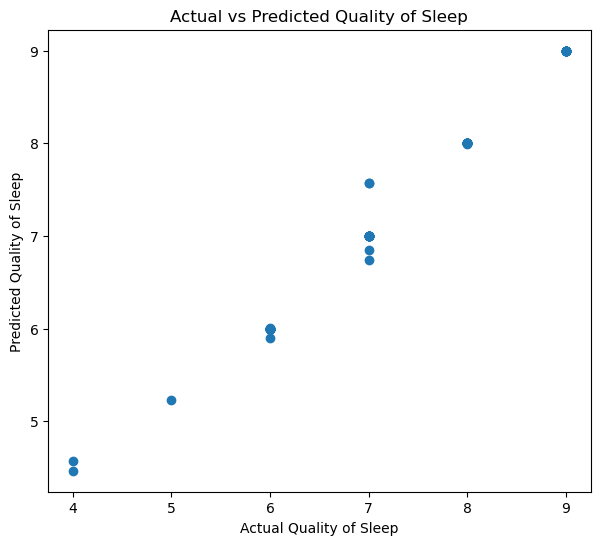

In [11]:
rf_predictions = models["Random Forest"].predict(X_test)

plt.figure(figsize=(7, 6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Quality of Sleep")
plt.ylabel("Predicted Quality of Sleep")
plt.title("Actual vs Predicted Quality of Sleep")

plt.show()

## 8. Save Baseline Results

The baseline model comparison is saved so that the results can be referenced during later model development.

In [12]:
results_df.to_csv(
    "../reports/baseline_model_results.csv",
    index=False
)

print("Baseline model results saved.")

Baseline model results saved.


## 9. Baseline Modeling Summary

The baseline models provide an initial benchmark for predicting Quality of Sleep.

The Dummy Regressor establishes a minimum reference performance. Linear Regression and Ridge Regression provide simple linear baselines, while Random Forest provides a nonlinear baseline capable of modeling more complex relationships.

Future modeling work will focus on improving upon the strongest baseline while avoiding overfitting and maintaining reliable evaluation on unseen data.